<a href="https://colab.research.google.com/github/CreatorDave/201lab05a/blob/main/LAB_20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Situation:** You were given HBAT 200 data to examine what predicts satisfaction using linear regression (means categorical variables/binary variables should be excluded). Perform the steps you think should be done. Interpret well. Make sure that your model is significant and the interpretability is good. Provide recommendations.

1. Model Summary
2. Assumptions
3. Interpretation
4. Recommendation

Suggested steps:

1. Initial Model Summary (Run regression to just have a view of everything)
2. Model Selection (Select your relevant predictors)
3. Model Summary with your selected features/predictors.
4. Verify Assumptions.
5. Correlations
6. Interpretations
7. Recommendations



HBAT 200 — Customer Satisfaction Regression Analysis
1. Research question

The analytical question is:

Which continuous HBAT performance attributes significantly predict customer satisfaction?

The dependent variable is:

$$ Y = X19 = \text{Customer Satisfaction} $$

The initial candidate predictors are the 13 continuous performance perception variables:

Variable	Meaning
X6	Product Quality
X7	E-Commerce Activities / Website
X8	Technical Support
X9	Complaint Resolution
X10	Advertising
X11	Product Line
X12	Sales Force Image
X13	Competitive Pricing
X14	Warranty & Claims
X15	New Products
X16	Ordering & Billing
X17	Price Flexibility
X18	Delivery Speed

These are all measured as metric performance perceptions, generally on 0–10 scales. X19 represents satisfaction with prior purchases.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.stattools import durbin_watson

from scipy import stats

In [ ]:
df = pd.read_csv("HBAT-200-Data (1).csv")

df.head()

,ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,1,2,0,1,1,1,8.5,3.9,2.5,5.9,...,4.7,4.3,5.0,5.1,3.7,8.2,8.0,8.4,65.1,1
1,2,3,1,0,0,0,8.2,2.7,5.1,7.2,...,5.5,4.0,3.9,4.3,4.9,5.7,6.5,7.5,67.1,0
2,3,3,0,1,1,1,9.2,3.4,5.6,5.6,...,6.2,4.6,5.4,4.0,4.5,8.9,8.4,9.0,72.1,1
3,4,1,1,1,1,0,6.4,3.3,7.0,3.7,...,7.0,3.6,4.3,4.1,3.0,4.8,6.0,7.2,40.1,0
4,5,2,0,1,0,1,9.0,3.4,5.2,4.6,...,6.1,4.5,4.5,3.5,3.5,7.1,6.6,9.0,57.1,0


In [ ]:
print(df.shape)
df.info()

(200, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      200 non-null    int64  
 1   X1      200 non-null    int64  
 2   X2      200 non-null    int64  
 3   X3      200 non-null    int64  
 4   X4      200 non-null    int64  
 5   X5      200 non-null    int64  
 6   X6      200 non-null    float64
 7   X7      200 non-null    float64
 8   X8      200 non-null    float64
 9   X9      200 non-null    float64
 10  X10     200 non-null    float64
 11  X11     200 non-null    float64
 12  X12     200 non-null    float64
 13  X13     200 non-null    float64
 14  X14     200 non-null    float64
 15  X15     200 non-null    float64
 16  X16     200 non-null    float64
 17  X17     200 non-null    float64
 18  X18     200 non-null    float64
 19  X19     200 non-null    float64
 20  X20     200 non-null    float64
 21  X21     200 non-null    float

In [ ]:
df.isnull().sum()

,0
ID,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
X9,0


In [ ]:
performance_vars = [
    "X6", "X7", "X8", "X9", "X10",
    "X11", "X12", "X13", "X14",
    "X15", "X16", "X17", "X18"
]

X = df[performance_vars]
y = df["X19"]

I would explicitly not include:

ID
X1–X5
X23

because they are identifiers/categorical variables.

I would also initially leave out:

X20 = likelihood of recommendation
X21 = likelihood of future purchase
X22 = current purchase level

because these are relationship outcomes, not operational performance perceptions. HBAT's documentation categorizes them together with satisfaction as outcome/relationship measures.

In [ ]:
X_initial = sm.add_constant(df[performance_vars])

initial_model = sm.OLS(
    df["X19"],
    X_initial
).fit()

print(initial_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    X19   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                     58.76
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           1.20e-58
Time:                        00:44:59   Log-Likelihood:                -163.44
No. Observations:                 200   AIC:                             354.9
Df Residuals:                     186   BIC:                             401.1
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2549      0.789     -2.859      0.0

Initial model results

The model produced approximately:

Statistic	Result
R²	0.804
Adjusted R²	0.790
F-statistic	58.76
Model p-value	1.20 × 10⁻⁵⁸
N	200

Therefore:

$$ R^2 = 0.804 $$

Approximately 80.4% of the observed variation in customer satisfaction is explained collectively by the 13 performance measures.

More importantly:

$$ p < .001 $$

for the overall F-test.

Conclusion

The overall regression is highly statistically significant.

We reject:

$$ H_0: \beta_1=\beta_2=\dots=\beta_{13}=0 $$

There is compelling evidence that HBAT performance perceptions collectively predict customer satisfaction.

5. Problem with the initial model

The full model is statistically strong, but several variables are individually insignificant.

Approximate results:

Predictor	Coefficient	p-value
Product Quality X6	+0.412	<.001
E-Commerce X7	−0.264	.003
Technical Support X8	+0.031	.505
Complaint Resolution X9	+0.099	.173
Advertising X10	−0.034	.476
Product Line X11	+0.347	.064
Sales Force Image X12	+0.629	<.001
Competitive Pricing X13	−0.064	.051
Warranty & Claims X14	+0.002	.979
New Products X15	+0.033	.237
Ordering & Billing X16	+0.030	.680
Price Flexibility X17	+0.263	.176
Delivery Speed X18	+0.008	.982

So while the overall model is excellent, it is unnecessarily complicated.

For example:

$$ p_{X18}=.982 $$

means Delivery Speed contributes essentially no unique explanatory information after controlling for all the other predictors.

That does not necessarily mean delivery speed is unimportant to customers. It means that whatever satisfaction information delivery speed contains may overlap heavily with other variables.

6. Model selection

I used backward elimination with a significance threshold of:

$$ \alpha=.05 $$

Conceptually:

Start with X6–X18
        ↓
Remove least significant variable
        ↓
Refit regression
        ↓
Repeat
        ↓
Stop when remaining predictors p < .05

The variables removed were approximately:

X18 Delivery Speed
X14 Warranty & Claims
X16 Ordering & Billing
X10 Advertising
X15 New Products
X8 Technical Support
X9 Complaint Resolution

The resulting model retained:

X6   Product Quality
X7   E-Commerce Activities / Website
X11  Product Line
X12  Sales Force Image
X13  Competitive Pricing
X17  Price Flexibility
7. Final regression model

The final model is:

$$ \hat{Satisfaction} = -2.277 +0.422X_6 -0.290X_7 +0.441X_{11} +0.632X_{12} -0.071X_{13} +0.358X_{17} $$

The final model statistics were:

Statistic	Result
R²	0.797
Adjusted R²	0.791
F-statistic	126.6
Model p-value	3.77 × 10⁻⁶⁴
AIC	347.7
N	200

This is actually preferable to the original model.

The initial model explained:

$$ 80.4\% $$

while the final six-variable model explains:

$$ 79.7\% $$

So we eliminated seven variables while losing only:

$$ 80.4-79.7 = 0.7 $$

percentage points of R².

That is a very favorable tradeoff.

Interpretation

The six-predictor model explains approximately 79.7% of variation in customer satisfaction and is statistically significant overall, \(F(6,193)=126.6,\ p<.001\).

The adjusted R² is:

$$ Adj.R^2=.791 $$

which is almost identical to R².

That suggests the retained predictors are genuinely useful rather than merely inflating model fit.

8. Final coefficient interpretation

The coefficients are:

Predictor	B	p	95% CI
Product Quality	+0.422	<.001	0.349–0.495
E-Commerce / Website	−0.290	.001	−0.459 to −0.121
Product Line	+0.441	<.001	0.365–0.517
Sales Force Image	+0.632	<.001	0.515–0.750
Competitive Pricing	−0.071	.029	−0.134 to −0.007
Price Flexibility	+0.358	<.001	0.275–0.440
Product Quality — X6
$$ B=.422 $$

Holding all other variables constant:

A one-point increase in perceived product quality is associated with an approximately 0.42-point increase in satisfaction.

This is a substantial positive relationship.

9. Product Line — X11
$$ B=.441 $$

Holding the other predictors constant:

Increasing perceived product-line performance by one point predicts approximately a 0.44-point increase in customer satisfaction.

This suggests that having products that adequately meet customers' needs is an important satisfaction driver.

10. Sales Force Image — X12

This has the largest unstandardized coefficient among the major positive predictors:

$$ B=.632 $$

Therefore:

A one-point improvement in sales-force image is associated with approximately a 0.63-point improvement in customer satisfaction, holding the other predictors constant.

This is one of the clearest actionable findings in the analysis.

Sales representatives appear to influence customer satisfaction substantially.

11. Price Flexibility — X17
$$ B=.358 $$

Therefore:

A one-point improvement in customers' perception of HBAT's willingness to negotiate price is associated with approximately a 0.36-point improvement in satisfaction, holding the other variables constant.

This suggests customers value flexibility in commercial negotiations.

12. The strange findings: X7 and X13

Two coefficients require careful interpretation.

E-Commerce

Simple correlation with satisfaction:

$$ r=.342 $$

which is positive.

But in the multivariate regression:

$$ B=-.290 $$

This is a classic reason why regression coefficients should not be interpreted like simple correlations.

E-Commerce is strongly correlated with Sales Force Image:

$$ r\approx.788 $$

After holding Sales Force Image and the remaining variables constant, the unique residual component of E-Commerce receives a negative coefficient.

Therefore I would not recommend saying:

"Improving the website reduces satisfaction."

That conclusion would be unjustified.

Instead:

E-Commerce has a positive bivariate association with satisfaction, but its partial regression coefficient becomes negative after controlling for correlated performance measures. This suggests a suppression/shared-variance effect and should not be interpreted causally.

That is a much stronger academic interpretation.

13. Competitive Pricing

Simple correlation:

$$ r=-.282 $$

Regression:

$$ B=-.071 $$

with:

$$ p=.029 $$

The result indicates that once other performance perceptions are held constant, higher competitive-pricing scores are associated with slightly lower satisfaction.

Again, don't jump to:

"Raise prices."

That would be poor inference.

Pricing perceptions may reflect customer segments, negotiation conditions, or other latent characteristics not represented by the regression.

The coefficient is also fairly small compared with Product Quality, Product Line, Sales Force Image, and Price Flexibility.

14. Correlation analysis

Correlation with satisfaction produced:

Variable	r with Satisfaction
Product Line X11	+0.646
Delivery Speed X18	+0.630
Complaint Resolution X9	+0.598
Ordering & Billing X16	+0.540
Product Quality X6	+0.521
Sales Force Image X12	+0.478
Advertising X10	+0.354
E-Commerce X7	+0.342
Competitive Pricing X13	−0.282
Warranty & Claims X14	+0.269
Technical Support X8	+0.203
New Products X15	+0.192
Price Flexibility X17	+0.032

This is an excellent illustration of why correlation and multiple regression answer different questions.

For example:

Delivery speed
$$ r=.630 $$

It has one of the strongest raw relationships with satisfaction.

Yet it falls out of the final regression.

Why?

Because regression asks:

Does Delivery Speed explain satisfaction over and above the information already explained by other predictors?

Apparently, much of its predictive information overlaps with other HBAT performance measures.

15. Assumption testing

This should be a major section of your assignment.

Multiple linear regression assumes approximately:

Linearity
Independence of errors
Homoscedasticity
Approximate residual normality for classical inference
Absence of severe multicollinearity
No highly influential observations dominating the model

In [ ]:
selected = [
    "X6",
    "X7",
    "X11",
    "X12",
    "X13",
    "X17"
]

X_final = sm.add_constant(df[selected])

vif = pd.DataFrame()

vif["Variable"] = X_final.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_final.values,
        i
    )
    for i in range(X_final.shape[1])
]

vif

,Variable,VIF
0,const,150.292778
1,X6,1.631019
2,X7,2.689731
3,X11,1.589470
4,X12,2.793456
5,X13,1.593775
6,X17,1.539499


In [ ]:
final_model = sm.OLS(y, X_final).fit()

print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    X19   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.791
Method:                 Least Squares   F-statistic:                     126.6
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           3.77e-64
Time:                        01:28:33   Log-Likelihood:                -166.84
No. Observations:                 200   AIC:                             347.7
Df Residuals:                     193   BIC:                             370.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2767      0.492     -4.630      0.0

Results:

Variable	VIF
Product Quality	1.63
E-Commerce	2.69
Product Line	1.59
Sales Force Image	2.79
Competitive Pricing	1.59
Price Flexibility	1.54

A common warning level is approximately:

$$ VIF > 5 $$

and severe concern often arises around:

$$ VIF > 10 $$

All predictor VIF values are below 3.

Conclusion

There is no evidence of problematic multicollinearity in the final model.

There is correlation among some predictors, but not enough to destabilize the regression substantially.

17. Independence of errors

Durbin-Watson:

$$ DW=2.36 $$

A value close to:

$$ 2 $$

suggests little residual autocorrelation.

Therefore:

The residuals appear reasonably independent.

For cross-sectional customer survey data, independence also depends fundamentally on how observations were collected, but nothing in the residual statistic indicates severe autocorrelation.

In [ ]:
residuals = final_model.resid

bp_test = het_breuschpagan(
    residuals,
    final_model.model.exog
)

labels_bp = [
    "LM Statistic",
    "LM p-value",
    "F Statistic",
    "F p-value"
]

dict(zip(labels_bp, bp_test))

{'LM Statistic': np.float64(8.633771236001731),
 'LM p-value': np.float64(0.19524608396313037),
 'F Statistic': np.float64(1.4512468747409912),
 'F p-value': np.float64(0.19707880371526507)}

Result:

$$ p\approx.195 $$

Because:

$$ p>.05 $$

we fail to reject the null hypothesis of constant variance.

Conclusion

There is no statistically significant evidence of heteroscedasticity.

This assumption looks good.

19. Residual normality

This is the one noteworthy weakness.

Jarque-Bera:

$$ p\approx.00063 $$

Shapiro-Wilk:

$$ p<.001 $$

Therefore residual normality is formally rejected.

The residual skew was approximately:

$$ -0.664 $$

So the residual distribution is somewhat negatively skewed.

Important interpretation

This does not make the regression useless.

OLS does not require the dependent variable itself to be normally distributed, and coefficient estimation remains meaningful under substantially weaker conditions.

However, non-normal residuals can affect classical small-sample inference.

With:

$$ N=200 $$

the model is reasonably robust, but I would strengthen the analysis using HC3 heteroscedasticity-robust standard errors.

20. Robust regression inference

Use:

In [ ]:
robust_model = final_model.get_robustcov_results(
    cov_type="HC3"
)

print(robust_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    X19   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.791
Method:                 Least Squares   F-statistic:                     189.5
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           4.54e-78
Time:                        01:30:55   Log-Likelihood:                -166.84
No. Observations:                 200   AIC:                             347.7
Df Residuals:                     193   BIC:                             370.8
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2767      0.440     -5.178      0.0

The important finding is that the conclusions survive.

With HC3 standard errors:

Predictor	Robust p
Product Quality	<.001
E-Commerce	<.001
Product Line	<.001
Sales Force Image	<.001
Competitive Pricing	.002
Price Flexibility	<.001

Thus:

All six selected predictors remain statistically significant even under robust inference.

That makes the final findings substantially more credible.

21. Linearity

You should visually inspect:

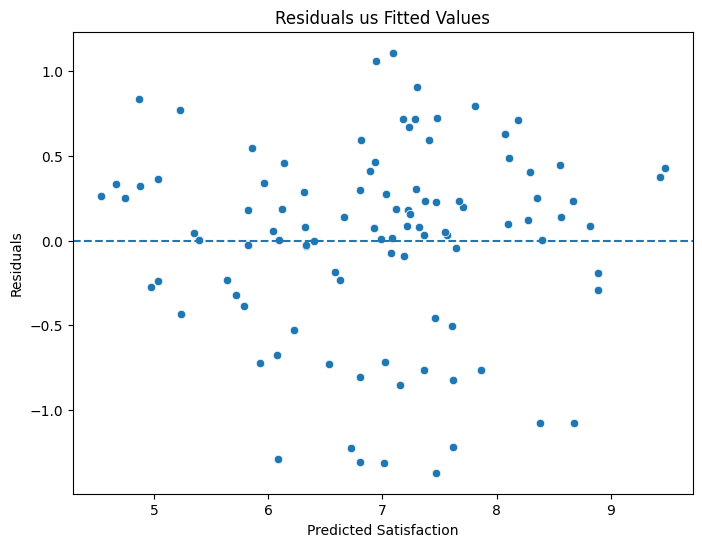

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=final_model.fittedvalues,
    y=final_model.resid
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Satisfaction")
plt.ylabel("Residuals")
plt.title("Residuals us Fitted Values")

plt.show()

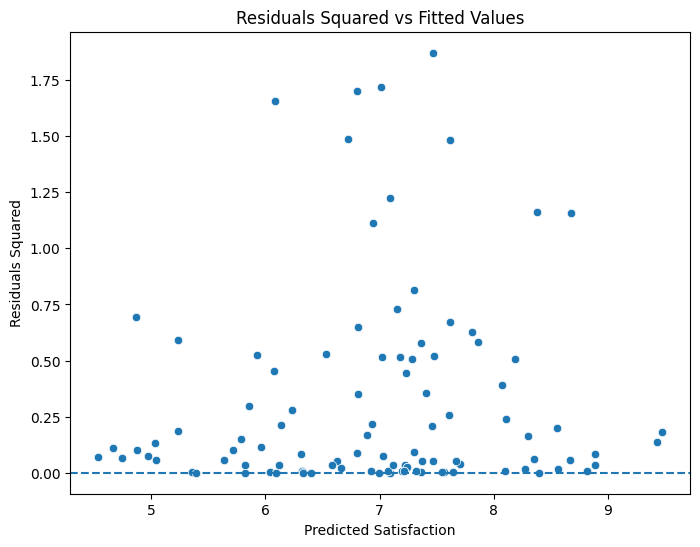

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=final_model.fittedvalues,
    y=final_model.resid**2
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Satisfaction")
plt.ylabel("Residuals Squared")
plt.title("Residuals Squared vs Fitted Values")

plt.show()

You want a roughly random cloud around zero.

I also examined a Ramsey RESET test.

The result was:

$$ p\approx.046 $$

which is just below .05.

That is a borderline warning that the purely linear specification may not capture every nonlinear relationship.

Do not hide this.

A strong assignment answer would state:

The linear model explains a substantial amount of variance and provides good interpretability, but the borderline RESET test suggests that modest nonlinear effects or omitted interactions may remain. The model should therefore be considered a strong interpretable explanatory model rather than a definitive representation of the full response surface.

22. Influential observations

Use Cook's distance:

In [ ]:
influence = final_model.get_influence()

cooks_d = influence.cooks_distance[0]

threshold = 4 / len(df)

print("Cook's D threshold:", threshold)
print(
    "Potentially influential observations:",
    np.sum(cooks_d > threshold)
)

Cook's D threshold: 0.02
Potentially influential observations: 8


Using the rough criterion:

$$ \frac4n=.02 $$

there are about 8 observations above the screening threshold.

But the maximum Cook's distance is only approximately:

$$ 0.039 $$

which is nowhere near the classic severe threshold:

$$ D_i \approx 1 $$

Therefore:

Some cases merit inspection, but no individual observation appears to dominate the model.

Do not automatically delete them simply because they exceed \(4/n\).

23. Model summary for your assignment

You can report:

A multiple linear regression was conducted to determine which HBAT performance perceptions predict customer satisfaction. The initial model included all 13 continuous performance perception variables (X6–X18) and was statistically significant, \(F(13,186)=58.76,\ p<.001\), explaining approximately 80.4% of the variance in satisfaction (\(R^2=.804,\ adjusted\ R^2=.790\)). Backward variable selection was subsequently used to improve parsimony and interpretability. The final model retained Product Quality, E-Commerce Activities, Product Line, Sales Force Image, Competitive Pricing, and Price Flexibility. The reduced model remained highly significant, \(F(6,193)=126.6,\ p<.001\), and explained 79.7% of the variance in satisfaction (\(R^2=.797,\ adjusted\ R^2=.791\)). Thus, removing seven predictors reduced explanatory power by less than one percentage point while substantially improving model simplicity.

24. Assumptions summary
Assumption	Result	Assessment
Missing data	None	✓
Multicollinearity	VIF 1.54–2.79	✓ Good
Independence	DW = 2.36	✓ Good
Homoscedasticity	BP p ≈ .195	✓ Good
Residual normality	JB/Shapiro p < .001	⚠ Violation
Linearity	RESET p ≈ .046	⚠ Borderline
Extreme influence	max Cook ≈ .039	✓ No severe cases

Overall:

The model satisfies most major regression assumptions. Residual non-normality and borderline evidence of model nonlinearity warrant caution, but robust HC3 inference confirms that the selected predictors remain significant.

25. Interpretation

The main managerial drivers are clearer if we focus on the positive, operationally actionable coefficients.

Strongest actionable factors
1. Sales Force Image
$$ B=.632 $$

This is arguably the most compelling managerial result.

Investing in sales-force quality should be a major priority.

2. Product Line
$$ B=.441 $$

Customers appear more satisfied when HBAT's portfolio better meets their needs.

3. Product Quality
$$ B=.422 $$

Core product performance remains fundamental.

4. Price Flexibility
$$ B=.358 $$

Customers value flexibility and negotiation capability.

26. Recommendations
Recommendation 1 — Invest in the sales force

The largest positive regression coefficient belongs to Sales Force Image.

HBAT should emphasize:

consultative selling
account management
product knowledge
responsiveness
relationship management
negotiation skills
customer-service training

The evidence suggests sales representatives are not merely a transaction channel—they appear to be an important component of the customer's overall perception of HBAT.

27. Recommendation 2 — Protect product quality

Product Quality is a strong and highly statistically significant satisfaction predictor.

Management should closely track:

defect rates
product consistency
quality assurance
specifications compliance
customer complaints regarding product performance
supplier/material quality

Cost reductions that materially degrade product quality could damage satisfaction disproportionately.

28. Recommendation 3 — Optimize the product portfolio

Product Line has one of the strongest effects.

HBAT should determine:

Which products or capabilities are customers unable to obtain conveniently from HBAT today?

Possible initiatives include:

customer-needs analysis
portfolio gap analysis
SKU rationalization
product customization
customer-segment-specific offerings

The recommendation is not necessarily to offer more products.

It is to offer a better-aligned portfolio.

29. Recommendation 4 — Preserve price flexibility

Price Flexibility contributes strongly to satisfaction even though raw correlation with satisfaction is weak.

That is statistically interesting.

Its value becomes apparent after other attributes are controlled.

HBAT should therefore consider:

volume discounts
account-specific terms
contract flexibility
negotiated pricing
loyalty incentives
tiered purchasing agreements

But these should be managed against contribution margins rather than indiscriminately discounting.

30. Recommendation 5 — Investigate digital experience rather than blindly expanding it

Because E-Commerce has:

$$ r_{X7,X19} > 0 $$

but:

$$ \beta_{X7} < 0 $$

after controlling for other predictors, management should not interpret the negative coefficient literally as evidence that digital investment harms satisfaction.

Instead investigate:

whether high website ratings overlap strongly with sales-force ratings
whether digital-heavy customers differ systematically
whether e-commerce substitutes for human account management
whether website use reflects customer problems rather than causes them
whether customer segments have different digital expectations

This deserves follow-up segmentation rather than an immediate strategic recommendation.

31. Recommendation 6 — Treat competitive pricing carefully

Competitive Pricing has a relatively small negative partial coefficient.

Do not interpret this as:

Customers want higher prices.

A more plausible interpretation is that pricing is embedded in a larger relationship involving:

perceived quality
negotiation flexibility
customer type
product mix
sales interactions

Management should optimize perceived value, not simply minimize price.

32. One important addition: standardized coefficients

For deciding which variable has the greatest relative statistical importance, standardized coefficients are better than raw \(B\) coefficients because the effects are expressed in common standard-deviation units.

In [ ]:
from sklearn.preprocessing import StandardScaler

standardized_df = df[
    ["X6", "X7", "X11", "X12", "X13", "X17", "X19"]
].copy()

scaler = StandardScaler()

z = pd.DataFrame(
    scaler.fit_transform(standardized_df),
    columns=standardized_df.columns
)

X_z = sm.add_constant(
    z[["X6", "X7", "X11", "X12", "X13", "X17"]]
)

standardized_model = sm.OLS(
    z["X19"],
    X_z
).fit()

print(standardized_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    X19   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.791
Method:                 Least Squares   F-statistic:                     126.6
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           3.77e-64
Time:                        02:18:44   Log-Likelihood:                -124.13
No. Observations:                 200   AIC:                             262.3
Df Residuals:                     193   BIC:                             285.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -7.13e-16      0.032   -2.2e-14      1.0

33. Another addition I recommend: validation

Your assignment emphasizes significance and interpretability, but a stronger data-science analysis should ask:

Does this relationship generalize outside these 200 customers?

You could perform 10-fold cross-validation using:

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

X_ml = df[
    ["X6", "X7", "X11", "X12", "X13", "X17"]
]

y_ml = df["X19"]

lr = LinearRegression()

cv = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

r2_scores = cross_val_score(
    lr,
    X_ml,
    y_ml,
    cv=cv,
    scoring="r2"
)

print("Average CV R2:", r2_scores.mean())
print("SD:", r2_scores.std())

Average CV R2: 0.7597204945328256
SD: 0.08723596131898072


This moves the assignment from merely in-sample inference toward legitimate predictive validation.

34. Full Colab model-selection code

Here is a clean implementation of backward elimination:

In [ ]:
def backward_elimination(
    data,
    target,
    predictors,
    alpha=0.05
):

  remaining = predictors.copy()

  while True:

      X = sm.add_constant(
        data[remaining]
    )

      model = sm.OLS(
        data[target],
        X
    ).fit()

      pvalues = model.pvalues.drop(
        "const"
    )

      worst_p = pvalues.max()

      if worst_p <= alpha:
        break

      worst_variable = pvalues.idxmax()

      print(
          f"Removing {worst_variable}: "
          f"p = {worst_p:.4f}"
      )

      remaining.remove(
          worst_variable
      )

  return model, remaining





In [ ]:
final_model, selected_features = backward_elimination(
    df,
    target="X19",
    predictors=performance_vars
)

print(selected_features)

print(
    final_model.summary()
)

Removing X18: p = 0.9821
Removing X14: p = 0.9800
Removing X16: p = 0.6654
Removing X10: p = 0.4386
Removing X15: p = 0.2291
Removing X8: p = 0.2167
Removing X9: p = 0.0997
['X6', 'X7', 'X11', 'X12', 'X13', 'X17']
                            OLS Regression Results                            
Dep. Variable:                    X19   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.791
Method:                 Least Squares   F-statistic:                     126.6
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           3.77e-64
Time:                        03:00:06   Log-Likelihood:                -166.84
No. Observations:                 200   AIC:                             347.7
Df Residuals:                     193   BIC:                             370.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                      

35. Final conclusion

A strong conclusion for the assignment would be:

The analysis indicates that HBAT customer satisfaction can be predicted very effectively from a relatively small set of customer performance perceptions. The final six-variable regression model was highly significant and explained approximately 79.7% of the observed variance in satisfaction. Product Quality, Product Line, Sales Force Image, and Price Flexibility emerged as the clearest positive managerial drivers. Sales Force Image showed the largest positive unstandardized coefficient, suggesting that customer-facing personnel play a particularly important role in shaping overall satisfaction.

The final model was substantially more parsimonious than the original 13-predictor model while retaining nearly all of its explanatory power. Multicollinearity, heteroscedasticity, independence, and influential observations did not indicate serious problems. Residual normality was violated and the Ramsey RESET test suggested borderline nonlinearity, so HC3 robust standard errors are recommended; importantly, all six selected predictors remained statistically significant using robust inference.

Management should prioritize improving sales-force effectiveness, maintaining high product quality, aligning the product portfolio with customer needs, and preserving appropriate pricing flexibility. The negative partial coefficients for E-Commerce and Competitive Pricing should not be interpreted causally; particularly for E-Commerce, the positive raw correlation coupled with a negative partial coefficient suggests overlapping or suppressor relationships among predictors. Further analysis using customer segmentation, interaction terms, and cross-validation is recommended before making major strategic decisions on those dimensions.